In [25]:
#%pip install torch torchvision fastai datasets pytorch-pretrained-biggan nltk torcheval
#%pip install pytorch-msssim
#%pip install numpy==1.26.4

In [26]:
# get the python version
import sys
print(sys.version)
is_38 = sys.version_info >= (3, 8)

3.8.18 (default, Sep 11 2023, 08:17:16) 
[Clang 14.0.6 ]


In [27]:
import torch
import numpy as np
import os

from torchvision import datasets
from torchvision import transforms
import torchvision.transforms as T

import matplotlib.pyplot as plt
import pandas as pd

from numpy import genfromtxt

from PIL import Image

import random

# import visiondataset
from torchvision.datasets import VisionDataset
import pandas as pd

In [28]:
import pickle
from typing import Any, Callable, Dict, List, Optional, Tuple, Union
import torch.nn.functional as F
import os

class MyDataset(VisionDataset):
    def __init__(
        self,
        root: str = ".",
        transform: Optional[Callable] = None,
        target_transform: Optional[Callable] = None,
        download: bool = False,
        normalize: Tuple[float, float] = None,
    ) -> None:
        super().__init__(root, transform=transform, target_transform=target_transform)

        # tg is NaN
        self.labels = [ 'Ng', 'Pci', 'Ph', 'Ox', 'Ow' ]
        self.data, self.features = self._load_data(root, ij=normalize)

    def __getitem__(self, index: int) -> Tuple[Any, Any]:
        """
        Args:
            index (int): Index

        Returns:
            tuple: (image, target) where target is index of the target class.
        """
        # id, img, features = self.ids[index], self.data[index], self.features.iloc[index]
        img, features = self.data[index], torch.Tensor(self.features.iloc[index])

        # doing this so that it is consistent with all other datasets
        # to return a PIL Image
        # img = Image.fromarray(img.numpy().astype(np.uint8))
        

        # img = img.reshape(1400, 390, 3)
        # img = img.reshape(pixels, pixels, 3)
        # if self.transform is not None:
        #     img = self.transform(img)

        # if self.target_transform is not None:
        #     target = self.target_transform(target)
        # img = img.reshape(pixels**2, -1)

        return img, features

    def __len__(self) -> int:
        return len(self.data)
    
    def _load_data(self, root: str, ij: Tuple[float, float]):
        data = []
        features = []
        for file in os.listdir(root):
            if file.endswith('.jpg'):
                # load the image
                img = Image.open(os.path.join(root, file))
                # convert to numpy array
                img = torch.Tensor(np.array(img))
                # Reshape to [batch, channels, height, width] format
                # [1400, 390, 3] -> [1, 3, 1400, 390]
                tensor_reshaped = img.permute(2, 0, 1).unsqueeze(0)

                img = F.interpolate(tensor_reshaped, size=(pixels, pixels), mode='nearest')
                img = img.squeeze(0).permute(1, 2, 0)

                # convert to grayscale
                img = 0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]

                # flatten the image
                # img = img.flatten()
                data.append(img)

                fs = []
                parts = file.replace('.jpg', '').split('_')
                for part, label in zip(parts, ['tg'] + self.labels):
                    if label == 'tg':
                        # fs.append(np.nan)
                        continue
                    if not part.startswith(label):
                        raise ValueError(f"File {file} does not have {label} in the correct position.")

                    try:
                        val = part[len(label):]
                        fs.append(float(val))
                    except ValueError:
                        raise ValueError(f"Value {val} in file {file} is not a number.")
                features.append(fs)
            
        print(f"Loaded {len(data)} images and {len(features)} features from {root}")

        # resize the data now
        # TODO hmmmm
        # Convert the list of NumPy arrays to a single PyTorch tensor
        data = torch.stack(data)

        # batch x pixels x pixels
        # data = F.pad(data, (0, pixels-39, 0, pixels-140), value=0)
        # repeat every pixel 3 times along the width
        """
        [1, 2, 3] => [1, 1, 1, 2, 2, 2, 3, 3, 3]
        """
        # data = data.repeat_interleave(3, dim=2)
        # print the first row of the first image
        # data = F.pad(data, (0, pixels-117), value=0)


        data = 2 * (data / 255) - 1
        # print(data.shape)
        # print(data[0, 5, :])

        # 140x39 => 140*39=2^n^2 => sqrt(140*39) = 2^n => 73.8918128076 = 2^n => log2(ceil(73.8918128076)) = n => ceil(6.2094533656) = n
        # -_- i dont want nearest base2, but nearest square
        # 140*39 => ceil(sqrt(140*39)) = 74
        # way less fun, but better
        # 140*39 - 74*74 = 16B of padding

        # data = F.interpolate(data.unsqueeze(1), size=(128, 39), mode='nearest').squeeze(1)
        # TODO what
        # data = data.reshape(len(data), -1)
        # data = F.pad(data, (0, 4), value=-1)

        # NOTE convert features to dtype f32 for mps
        features = pd.DataFrame(features, columns=self.labels).astype('float32')

        if ij is not None:
            # NOTE: (-1, 1) => y = 2 * (x - min) / (max - min) - 1
            #       ( i, j) => y = (j-i) * (x - min) / (max - min) + i
            features = (ij[1] - ij[0]) * (features - features.min()) / (features.max() - features.min()) + ij[0]

        return data, features

Loaded 615 images and 615 features from data/gastemp

data: tensor([[ 0.9859,  0.9800,  0.9955,  0.9862,  0.9859,  0.9954,  0.9908,  0.9908,
          0.9908,  0.9908,  0.9908,  0.9954,  1.0000,  1.0000,  1.0000,  1.0000],
        [ 0.9768,  0.3733,  0.2525, -0.2978, -0.6890, -0.7729, -0.7729, -0.7729,
         -0.7729, -0.7729, -0.7729,  0.9920,  1.0000,  1.0000,  1.0000,  1.0000],
        [ 0.9932,  0.6441,  0.2955,  0.3996, -0.4195, -0.7070, -0.7729, -0.7729,
         -0.7729, -0.7729, -0.7729,  0.9752,  1.0000,  1.0000,  1.0000,  1.0000],
        [ 0.9920,  0.7488,  0.4181,  0.1926,  0.3054,  0.3627,  0.3169, -0.1090,
         -0.2931, -0.3179, -0.7190, -0.7704,  1.0000,  1.0000,  1.0000,  1.0000],
        [ 0.9826,  0.5832,  0.6038,  0.2274,  0.2883,  0.3196,  0.3644,  0.3823,
          0.3904,  0.3893,  0.3090,  0.0130,  0.9775,  1.0000,  1.0000,  1.0000],
        [ 0.9761,  0.4820,  0.6572,  0.2626,  0.2619,  0.3032,  0.3242,  0.3600,
          0.3811,  0.3823,  0.3867,  0.3974,

,Ng,Pci,Ph,Ox,Ow
0,-0.621,-1.0,0.0,-1.0,1.0


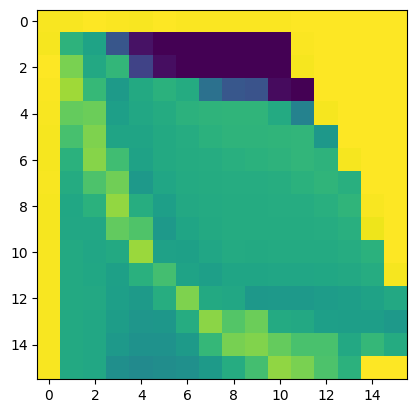

In [29]:
pixels = 16
dataset = MyDataset(root='data/gastemp', normalize=(-1, 1))
datum = dataset[0]
print(f"""
data: {datum[0]}
features: {datum[1]}
""")

# convert data to image plot
# TODO first pixel is bad
img = np.array(datum[0])
plt.imshow(img)

# img = img.reshape(-1, 128, 128)
# img = Image.fromarray((img * 255).astype(np.uint8)[0])
# plt.imshow(img)
# img2 = np.array(datum[0])
# img2 = img2[:-16].reshape(140, 39)
# plt.imshow(img2)

# downscale to 74x74
# remove the padding
# img = img[:-4].reshape(-1, 140, 39*3)
# img = img.reshape(-1, pixels, pixels)
# # img = F.interpolate(torch.Tensor(img).unsqueeze(0), size=(140, 39), mode='nearest').squeeze(0).numpy()
# print(img.shape)
# img = Image.fromarray((img * 255).astype(np.uint8)[0])
# plt.imshow(img)

conditions = np.array(datum[1])
features = pd.DataFrame([conditions], columns=dataset.labels)
display(features)

In [30]:
# get the count, mean, std, min, max, and sum of each column
df_aggregated = dataset.features.agg(['count', 'mean', 'std', 'min', 'max', 'sum']).reset_index()
display(df_aggregated)

# remove the tg column from the dataset
# dataset.features = dataset.features.drop(columns=['tg'])

,index,Ng,Pci,Ph,Ox,Ow
0,count,615.000000,615.000000,615.000000,615.000000,615.000000
1,mean,-0.418016,-0.469171,-0.609756,0.026558,-0.015718
2,std,0.539978,0.662467,0.706348,0.738824,0.678723
3,min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
4,max,1.000000,1.000000,1.000000,1.000000,1.000000
5,sum,-257.079987,-288.540009,-375.000000,16.333344,-9.666658


In [31]:
# get the memory usage so far
print(f"Memory usage: {dataset.features.memory_usage().sum()} bytes")

Memory usage: 12428 bytes


# CGAN

In [32]:

import torch
import numpy as np
import os

from torchvision import datasets
from torchvision import transforms
import torchvision.transforms as T

import matplotlib.pyplot as plt
import pandas as pd

from numpy import genfromtxt

from PIL import Image

import random

# import visiondataset
from torchvision.datasets import VisionDataset

In [33]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

In [34]:

from torch.utils.data import TensorDataset, DataLoader

import torch.optim as optim 
import torch.nn as nn


import torch.nn.functional as F

from torch.autograd import Variable

from fastai.vision.all import *
from fastai.vision.gan import *

from fastai.callback.all import *

In [35]:
from datasets import load_dataset, Split
import torch.autograd as autograd
from torcheval.metrics import PeakSignalNoiseRatio

In [36]:
channels = 1 ## 1 for B&W, 3 for RGB, 4 for RGBA

learning_rate    = 2e-4 #0.003  ## Adam default   ## 0.001 2e-4#
batch_size       = 16
N_Epochs         = 1833 #4_000  ##27000  
num_classes = 1
width = 39
height = 140
img_size = width*height*channels
certainty_repeater = 6# channels**2 - num_classes

print(f"{img_size}")

if torch.cuda.is_available():
    device = torch.device('cuda')
    # get number of cuda devices
    print(f"devices: {torch.cuda.device_count()}")
    print(f"device:  {torch.cuda.get_device_name()}")
    print(f"device0: {torch.cuda.get_device_properties(0)}")
    print(f"{torch.cuda.memory_summary()}")
elif torch.backends.mps is not None:
    device = torch.device('mps')
    print(f"{torch.mps.current_allocated_memory()}")
    os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
else:
    device = torch.device('cpu')
    # print a warning that cpu is being used
    print("Warning: Running on CPU. This will be slow.")
print(f"{device}")

5460
500194304
mps


In [37]:
# convert the dataset into a train / test split
# TODO i dont think test is used
# need to keep the split for each new run, to continue the epochs and same data
# TODO keep this, nicer, or use seed as file label
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.85, 0.15], generator=torch.Generator().manual_seed(42))

# define the dataloader
dl_train = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
dl_test = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [38]:

def plot_GAN_losses(losses: List[Tuple[float, float]]):
    losses_generator = [i[0] for i in losses]
    losses_critic = [i[1] for i in losses]

    n_epochs = [i for i in range(len(losses))]  

    plt.plot(n_epochs, losses_critic,      label = "critic") 
    plt.plot(n_epochs, losses_generator,  label = "generator")
    plt.legend() 
    plt.show()


In [39]:

def print_metrics_function(y_test, y_pred):
    print('Accuracy: %.2f' % accuracy_score(y_test, y_pred))
    confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
    print("Confusion Matrix:")
    print(confmat)
    print('Precision: %.3f' % precision_score(y_true=y_test, y_pred=y_pred, average='weighted'))
    print('Recall: %.3f' % recall_score(y_true=y_test, y_pred=y_pred, average='weighted'))
    f1_measure = f1_score(y_true=y_test, y_pred=y_pred, average='weighted')
    print('F1-mesure: %.3f' % f1_measure)
    return f1_measure, confmat


In [40]:
def plot_metric_per_epoch(the_scores_list):
    # metrics = {}
    # metrics = []
    print(the_scores_list[0])
    epochs = [ the_scores_list['epoch'] for metric in the_scores_list ]
    for metric in the_scores_list:
        test = [ the_scores_list[metric] for metric in the_scores_list ]

    # x_epochs = []
    # y_epochs = [] 
    # for i, val in enumerate(the_scores_list):
    #     x_epochs.append(i)
    #     y_epochs.append(val)
    
        plt.scatter(epochs, test ,s=50,c='lightgreen', marker='s', label='score')
        plt.xlabel('epoch')
        plt.ylabel('score')
        plt.title('Score per epoch')
        plt.legend()
        plt.grid()
        plt.show()

In [41]:
def get_metrics(epoch):
    # using train_dl each time anywhere will give different values each time
    test = [ x for x in test_dataset ]

    real = torch.stack([x[0] for x in test], dim=0).to(device)
    real = real.reshape(len(real), -1, pixels, pixels)

    labels = torch.stack([x[1] for x in test], dim=0).to(device)
    labels = labels.repeat(1, 3).to(device)

    rand = noise_batch(len(real)).to(device)
    noise = torch.cat( (rand, labels) , dim=1)
    fake = G_model.forward( noise )

    psnr = PeakSignalNoiseRatio(device=device)
    psnr.update(fake, real)

    real = real.detach().cpu()
    fake = fake.detach().cpu()
    labels = labels.detach().cpu()

    metric = {
        'sanity': labels[0], # should always be the same
        'epoch': epoch,
    }

    return metric, fake

In [42]:
def random_G_vector_input():
    rand_vec = torch.randn( 100 ).to(device)
    return rand_vec

In [43]:
def noise_batch(batch_size=None):
    if batch_size is None:
        return torch.randn(100).to(device)
    else:
        return torch.randn(batch_size, 100).to(device)

In [44]:
def random_G_batch_vector_input():
    rand_vec = torch.randn( (batch_size, 100 ) ).to(device)
    return rand_vec

In [45]:
def random_batch_one_hot_rc(batch_size, size):
    rand_vec = torch.zeros( (batch_size, num_classes ) ).to(device)
    for i in range(batch_size):
        random_idx = random.randint(0,size-1)
        rand_vec[i, random_idx] = 1.0
    return rand_vec

In [46]:
import datetime
import tqdm

losses = []
metrics = []
fakes = []

def training_loop(N_Epochs, G_model, D_model, D_loss_fn, G_opt, D_opt,
                  checkpoint='checkpoint', save_interval: int = None, stop_after: datetime.timedelta = None, start_epoch: int = None):
    global losses
    global metrics
    global fakes
    
    if start_epoch is not None:
        G_model.load_state_dict(torch.load(f"{checkpoint}/G_{start_epoch}.pt"))
        D_model.load_state_dict(torch.load(f"{checkpoint}/D_{start_epoch}.pt"))
        losses = torch.load(f"{checkpoint}/l_{start_epoch}.pkl")
        metrics = torch.load(f"{checkpoint}/m_{start_epoch}.pkl")
        fakes = torch.load(f"{checkpoint}/f_{start_epoch}.pkl")
        
        print(f"loaded {checkpoint}/*_{start_epoch}")
    else:
        start_epoch = 0
    
    start_time = datetime.datetime.now()
    last_time = datetime.datetime.min
    pbar = tqdm.tqdm(range(start_epoch, N_Epochs+1))
    # pbar.update(start_epoch) # update with start makes it double. only one does nothing
    
    # TODO pbar jump to start
    for epoch in pbar:
        # shuffle dl_train every epoch
        # dataset = MyDataset(root='data', normalize=(-1, 1), transform=transforms.Compose([
        #     transforms.RandomHorizontalFlip(),
        #     transforms.RandomVerticalFlip()
        # ]))
        # train_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.95, 0.05])
        dl_train = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        
        for xb, yb in dl_train:              ## xb = [batch, 1, 28, 28]
            xb, yb = xb.to(device), yb.to(device)
            # print the memory usage of mps

            if xb.shape[0] != batch_size:
                # print(f"skipping batch of size {xb.shape[0]}")
                continue

            # xb = xb.reshape(batch_size, 128, width)
            # xb = F.pad(xb, (0, 128-width, 0, 0), value=-1) # TODO set to min
            yb = yb.repeat(1, 3)
            xb = xb.reshape(batch_size, pixels, pixels)
            xb = torch.unsqueeze(xb, dim=1)
            # pad the image to 140x140
            # convert nb [batch, 384] to [batch, -1, 32, channels]

            yb_certainty = yb.repeat(channels, pixels, 1, 1).permute(2, 0, 1, 3)#1, 0, 2) # [ batch, x (classes), y, channels ]
            # yb_certainty = nb.reshape(batch_size, channels, pixels, -1)
            real = torch.cat( (xb, yb_certainty) , dim=3)
            # print the real image
            # plt.imshow(real[0].squeeze(0).cpu().detach().numpy())

            # print the real image TODO this will print nothing because it is normalized to highest number
            # plt.imshow(real[0].squeeze(0).cpu().detach().numpy())

            for _ in range(5):
                noise = torch.cat( (random_G_batch_vector_input(), yb) , dim=1)
                fake = G_model( noise )#.detach()
                real_pred = D_model( real  ).reshape(-1)
                inputs = torch.cat( (fake, yb_certainty) , dim=3)
                fake_pred = D_model(  inputs  ).reshape(-1)

                fake_loss   = D_loss_fn(D_model, inputs, real, real_pred, fake_pred)
                # D_opt.zero_grad()
                D_model.zero_grad()
                fake_loss.backward(retain_graph=True)
                D_opt.step()
                
            output = D_model( inputs ).reshape(-1)
            gen_loss = -torch.mean(output)
            G_model.zero_grad()
            gen_loss.backward()
            G_opt.step()


        if epoch % 1 == 0:
            loss = (
                gen_loss.cpu().detach().numpy(),
                fake_loss.cpu().detach().numpy()
            )
            losses.append(loss)
            D_gen_loss_rnd = np.round(loss[0], 3)
            D_fake_loss_rnd = np.round(loss[1], 3)

            # not rounded anymore :(
            message = f"gen: {D_gen_loss_rnd}; crit: {D_fake_loss_rnd}"
            pbar.set_description(message)
            
        # draw an image of each class
        # place them all on the same figure
        # if epoch % 100 == 0:
        if datetime.datetime.now() > last_time + datetime.timedelta(minutes=1):
            last_time = datetime.datetime.now()
            f, axarr = plt.subplots(nrows=1, ncols=4, figsize=(12,4))
            
            for i in range(2):
                label = dataset[i][1].unsqueeze(0).repeat(1, 3).to(device)

                # create noise and make it 2d
                noise = random_G_vector_input().unsqueeze(0)
                inputs = torch.cat( (noise, label) , dim=1)
                output = G_model( inputs ).squeeze(0).cpu()
                # convert output (batch, img_size) to (batch, 4, 32, 32)
                if channels == 4 or channels == 3:
                    # output = output.reshape((-1, 4, pixels, pixels)) # wrong too, lol
                    output = output.reshape((-1, channels, pixels, pixels))
                    # output = output.reshape((-1, 32, 32))

                    img = output.permute(0, 2, 3, 1).detach().numpy()#.reshape(32,32)
                elif channels == 1:
                    img = output.detach().numpy()

                if channels == 4 or channels == 3:
                    mode = None
                elif channels == 1:
                    mode = 'L'

                # downscale to 74x74
                # TODO is this the best way, seems like the model gives a different output
                # 128x128 => 128*128 => 128*128-4 => 1x1x140x39*3 => 140x39
                # img = img.reshape(-1)[:-4].reshape(-1, channels, 140, 39*3)
                # img = F.interpolate(torch.Tensor(img), size=(140, 39), mode='nearest').squeeze(0).numpy()
                # remove the padding
                # img = img[:-16].reshape(-1, 140, 39)
                # img = img.reshape(-1)[:-4].reshape(-1, 140, 39*3)
                # TODO this one thing was * 0. so ofc it didnt work. had to compare to spot the slight difference
                # and i thought i fixed it. "no way it is in that code" "i kept checking it"
                img = Image.fromarray((img * 255).astype(np.uint8)[0], mode=mode)
                # display the image
                # (1, 16, 16) => (16, 16)
                
                axarr[i].imshow(img)

                # show the original image
                img = dataset[i][0].reshape(-1, pixels, pixels).cpu().detach().numpy()
                # img = img[:-4].reshape(-1, 140, 39*3)
                # img = F.interpolate(torch.Tensor(img).unsqueeze(0), size=(140, 39), mode='nearest').squeeze(0).numpy()
                axarr[i+2].imshow(Image.fromarray((img * 255).astype(np.uint8)[0], mode=mode))
            # Note that if showing the plot, plt.show(), shoudl follow plt.savefig(); otherwise, the file image will be blank.
            #   - stack overflow person
            # save the plot
            plt.savefig(f"{checkpoint}/epoch_{epoch}.png")
            plt.show()
            
            metric, fake = get_metrics(epoch)
            metrics.append(metric)
            fakes.append(fake)
        
        if save_interval is not None and epoch % save_interval == 0:
            torch.save(G_model.state_dict(), f"{checkpoint}/G_{epoch}.pt")
            torch.save(D_model.state_dict(), f"{checkpoint}/D_{epoch}.pt")
            
            torch.save(losses, f"{checkpoint}/l_{epoch}.pkl")
            torch.save(metrics, f"{checkpoint}/m_{epoch}.pkl")
            torch.save(fakes, f"{checkpoint}/f_{epoch}.pkl")
        
        if stop_after is not None and datetime.datetime.now() > start_time+stop_after:
            print(f"Stopping training because it has been {datetime.datetime.now() - start_time} since {start_time}")
            break

    torch.save(G_model.state_dict(), f"{checkpoint}/G_{epoch}.pt")
    torch.save(D_model.state_dict(), f"{checkpoint}/D_{epoch}.pt")
    torch.save(losses, f"{checkpoint}/l_{epoch}.pkl")
    torch.save(metrics, f"{checkpoint}/m_{epoch}.pkl")
    torch.save(fakes, f"{checkpoint}/f_{epoch}.pkl")

In [47]:
def grad_penatly(critic, real, fake):
    # Random weight term for interpolation between real and fake samples
    batch, c, h, w = real.shape
    epsilon = torch.rand((batch, 1, 1, 1)).repeat(1, c, h, w).to(device)
    interpolated_images = real * epsilon + fake * (1 - epsilon)

    # Calculate critic scores
    mixed_scores = critic(interpolated_images)
    gradient = torch.autograd.grad(
        inputs=interpolated_images,
        outputs=mixed_scores,
        grad_outputs=torch.ones_like(mixed_scores),
        create_graph=True,
        retain_graph=True,
    )[0]

    # Take the norm of the gradient
    gradient = gradient.view(gradient.shape[0], -1)
    grad_norm = gradient.norm(2, dim=1) # L2 norm (euclidean norm)
    gradient_penalty = torch.mean((grad_norm - 1) ** 2)
    return gradient_penalty

def wasserstein_loss(D_model, gen_img, real_data, real_pred, fake_pred):
    loss =  - (real_pred.mean() - fake_pred.mean()) + 10 * grad_penatly(D_model, real_data, gen_img)
    return loss

/Users/oniichan/anaconda3/envs/its530_py38/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/oniichan/anaconda3/envs/its530_py38/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
gen: 0.014999999664723873; crit: 64.62000274658203:   0%|          | 0/1834 [00:41<?, ?it/s]/var/folders/8v/kyhpjx6d3y1b7dp0twz_83sw0000gn/T/ipykernel_70709/2625314587.py:137: RuntimeWarning: invalid value encountered in cast
  img = Image.fromarray((img * 255).astype(np.uint8)[0], mode=mode)
/var/folders/8v/kyhpj

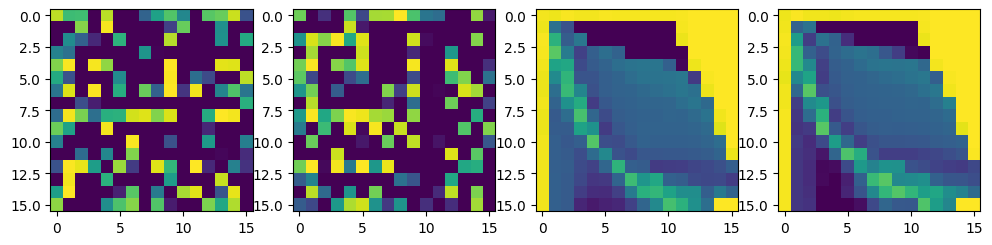

gen: 0.014999999664723873; crit: 64.62000274658203:   0%|          | 1/1834 [00:43<21:55:21, 43.06s/it]


KeyboardInterrupt: 

: 

In [ ]:
G_model     =  basic_generator(pixels, in_sz=100+5*3, n_channels=channels, n_extra_layers=1)

#import resnet 50
from torchvision.models import resnet50

# TODO storing it wrong. maybe see how they compare. something odd in it
# TODO but not that other thing. makes no sense. wouldnt even matter. and it works without
# maybe watch xb stuff
D_model = resnet50(pretrained=True)

# make resnet input same channels
D_model.conv1 = torch.nn.Conv2d(channels, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
# # Replace maxpool with avgpool (used to work without this, might be MPS thing)
D_model.maxpool = nn.AvgPool2d(kernel_size=3, stride=2, padding=1)
# make resnet output 2 classes
D_model.fc = torch.nn.Linear(in_features=2048, out_features=2, bias=True)

D_loss_fn = wasserstein_loss

G_opt       = torch.optim.Adam( G_model.parameters(), lr=learning_rate, betas=(0.0, 0.9) )
D_opt       = torch.optim.Adam( D_model.parameters(), lr=learning_rate, betas=(0.0, 0.9) )

# move everything to device
G_model.to(device)
D_model.to(device)

training_loop(  N_Epochs, G_model, D_model, D_loss_fn, G_opt, D_opt,
    checkpoint='checkpoint', save_interval=100, stop_after=None, start_epoch=None   )

# Validation

In [ ]:
def last_checkpoint(starter: str):
    return max([ f"checkpoint/{f}" for f in os.listdir('checkpoint') if f.startswith(starter) ], key=os.path.getctime)

G_model     =  basic_generator(pixels, in_sz=100+7*3, n_channels=channels, n_extra_layers=1).to(device)

# get the checkpoint with the latest date
checkpoint = last_checkpoint('G_')

# G_692 - basic, 128
G_model.load_state_dict(torch.load(f"{checkpoint}"))
print(f"loaded {checkpoint}")

losses = torch.load(last_checkpoint('l_'))
plot_GAN_losses(losses)

metrics = torch.load(last_checkpoint('m_'))
# plot_metric_per_epoch(metrics)

fakes = torch.load(last_checkpoint('f_'))
print(len(fakes), len(fakes[0]))
# print(metrics)

In [ ]:
test = [ x for x in test_dataset ] 

xb = torch.Tensor(test[0][0]).to(device).reshape(1, -1, pixels, pixels)

yb = torch.Tensor(test[0][1]).repeat(1, 3).to(device)

yb_certainty = yb.repeat(channels, pixels, 1, 1).permute(2, 0, 1, 3)#1, 0, 2) # [ batch, x (classes), y, channels ]
# yb_certainty = nb.reshape(batch_size, channels, pixels, -1)
real = torch.cat( (xb, yb_certainty) , dim=3).squeeze(0)

img = Image.fromarray((real.cpu().numpy() * 255).astype(np.uint8)[0])
plt.imshow(img)

In [ ]:
f, axarr = plt.subplots(2,3, figsize=(16,8))

test = [ x for x in test_dataset ] 

real = torch.Tensor(test[0][0]).to(device).reshape(1, -1, pixels, pixels)

labels = torch.Tensor(test[0][1]).repeat(1, 3).to(device)

print(labels[0])
for i in range(2):
    for j in range(3):
        if i == 0 and j == 0:
            img = real[0].detach().cpu().numpy()
        else:
            rand = random_G_vector_input().unsqueeze(0)
            
            label = labels[0].to(device).unsqueeze(0)
            noise = torch.cat( (rand, label) , dim=1)
            fake = G_model.forward( noise ).cpu()
            img = fake.squeeze(0).detach().numpy()

            # print(img.shape)
            # convert img to pil
            # img = img.reshape(-1)[:-4].reshape(-1, channels, 140, 39*3)
            img = img.reshape(-1).reshape(-1, pixels, pixels)
            # img = F.interpolate(torch.Tensor(img), size=(140, 39), mode='nearest').squeeze(0).numpy()
        img = Image.fromarray((img * 255).astype(np.uint8)[0], mode='L')
        # display the image
        # plt.imshow(img)
        axarr[i,j].set_title("real" if i == 0 and j == 0 else "fake")
        axarr[i,j].imshow(img)#, interpolation='none', cmap='Blues'

        # TODO print comparison

In [ ]:

from torcheval.metrics import PeakSignalNoiseRatio
from torcheval.metrics.image import FrechetInceptionDistance
from pytorch_msssim import ssim, ms_ssim

# fid = FrechetInceptionDistance(device=device)

# Generate some dummy data (replace with your real and generated images)
rand = random_G_vector_input().unsqueeze(0)
label = dataset[0][1].to(device).unsqueeze(0).repeat(1, 3)
noise = torch.cat( (rand, label) , dim=1)
fake = G_model.forward( noise )
print(fake.shape)

real = dataset[0][0].reshape(-1, pixels, pixels).unsqueeze(0).cuda()
print(real.shape)

In [ ]:
feats = [ 'tg', 'Ng', 'Pci', 'H', 'Ox', 'Ow', 'Hbt' ]
test = [ x for x in test_dataset ]

epoch = checkpoint.split('.')[0].replace('G_','')
print(epoch)

for k in range(5):
    f, axarr = plt.subplots(2,3, figsize=(16,8))

    real = torch.Tensor(test[k][0]).to(device).reshape(1, -1, pixels, pixels)
    labels = torch.Tensor(test[k][1]).repeat(1, 3).to(device)

    for i in range(2):
        for j in range(3):
            if i == 0 and j == 0:
                img = real[0].detach().cpu().numpy()
            else:
                rand = random_G_vector_input().unsqueeze(0)

                label = labels[0].to(device).unsqueeze(0)
                noise = torch.cat( (rand, label) , dim=1)
                fake = G_model.forward( noise ).cpu()
                img = fake.squeeze(0).detach().numpy()

                img = img.reshape(-1).reshape(-1, pixels, pixels)
            img = Image.fromarray((img * 255).astype(np.uint8)[0], mode='L')
            # display the image
            # plt.imshow(img)
            axarr[i,j].set_title("real" if i == 0 and j == 0 else "fake")
            axarr[i,j].imshow(img)

    # the title is the names of the features and the value of them (label and remove the repeat)
    f.suptitle(' '.join([ f"{f}: {round(l.item(), 3)}" for f, l in zip(feats, labels[0][:len(feats)]) ]), fontsize=16)
    plt.savefig(f"{epoch}-{k}.png")

# # Adjust the layout and save
# plt.tight_layout()
# f.savefig("test.png", dpi=300, bbox_inches='tight')

In [ ]:
import torch
from torcheval.metrics import FrechetInceptionDistance

fid = FrechetInceptionDistance()

real = torch.rand(64, 3, 299, 299)
fake = torch.rand(64, 3, 299, 299)

fid.update(real, is_real=True)
fid.update(fake, is_real=False)
score = fid.compute()
print(score)

In [ ]:
test = [ x for x in test_dataset ]
print(len([x[0] for x in test]), type(test[0][0]))

real = torch.stack([x[0] for x in test], dim=0).to(device)
print(real.shape, len(real))
real = real.reshape(len(real), -1, pixels, pixels)

labels = torch.stack([x[1] for x in test], dim=0).to(device)
print(labels.shape, len(labels))
labels = labels.repeat(1, 3).to(device)

rand = noise_batch(len(real)).to(device)
noise = torch.cat( (rand, labels) , dim=1)
fake = G_model.forward( noise )

In [ ]:
test = [ x for x in test_dataset ]

real = torch.stack([x[0] for x in test], dim=0).to(device)
real = real.reshape(len(real), -1, pixels, pixels)
real_fid = ((real + 1) / 2).repeat((1, 3, 1, 1))

psnrs = []
ssims = []
msssims = []
fids = []

for fake, metric in zip(fakes, metrics):
    fake = fake.to(device)
    
    psnr = PeakSignalNoiseRatio(device=device)
    psnr.update(fake, real)
    psnrs.append(psnr.compute())
    
    ssim_sc = ssim(real, fake, size_average=True)
    ssims.append(ssim_sc)
    msssim_sc = 0# ms_ssim(real, fake, size_average=True)
    # msssims.append(ms_ssim_sc)
    
    fid = FrechetInceptionDistance()
    fid.update(real_fid, is_real=True)
    fid.update(((fake + 1) / 2).repeat((1, 3, 1, 1)), is_real=False)
    fid_sc = fid.compute()
    fids.append(fid_sc)
    
    print(f"{metric['epoch']}:\t{psnr.compute()} Db;\tssim:{ssim_sc};\tms_ssim:{msssim_sc}\tfid_sc:{fid_sc}")

In [ ]:
# create a plot of the metrics
plt.plot([metric['epoch'] for metric in metrics], [psnr.cpu() for psnr in psnrs])
plt.xlabel('epoch')
plt.ylabel('PSNR')
plt.title('PSNR per epoch')

In [ ]:
# create a plot of the metrics
plt.plot([metric['epoch'] for metric in metrics], [ ssim.cpu() for ssim in ssims])
plt.xlabel('epoch')
plt.ylabel('SSIMS')
plt.title('SSIM per epoch')

In [ ]:
# create a plot of the metrics
plt.plot([metric['epoch'] for metric in metrics], [ fid.cpu() for fid in fids])
plt.xlabel('epoch')
plt.ylabel('FIDS')
plt.title('FID per epoch')

In [ ]:
test = [ x for x in test_dataset ]

real = torch.stack([x[0] for x in test], dim=0).to(device)
real = real.reshape(len(real), -1, pixels, pixels)
real_fid = ((real + 1) / 2).repeat((1, 3, 1, 1))

psnrs = []
ssims = []
fids = []

for i in range(100):
    metrics, fake = get_metrics(i)
    fake = fake.to(device)
    
    psnr = PeakSignalNoiseRatio(device=device)
    psnr.update(fake, real)
    psnrs.append(psnr.compute().cpu().numpy())
    
    ssim_sc = ssim(real, fake, size_average=True)
    ssims.append(ssim_sc.cpu().numpy())
    
    fid = FrechetInceptionDistance()
    fid.update(real_fid, is_real=True)
    fid.update(((fake + 1) / 2).repeat((1, 3, 1, 1)), is_real=False)
    fid_sc = fid.compute()
    fids.append(fid_sc.cpu().numpy())
    
    print(f"{metrics['epoch']}:\t{psnr.compute()} Db;\tssim:{ssim_sc};\tfid_sc:{fid_sc}")

In [ ]:
# get the mean and std of the metrics
for name, metric in zip(['PSNR', 'SSIM', 'FID'], [psnrs, ssims, fids]):
    scores = [ m for m in metric ]
    print(f"{name}:\t{np.mean(scores)} ± {np.std(scores)}")

In [ ]:
for name, metric in zip(['PSNR', 'SSIM', 'FID'], [psnrs, ssims, fids]):
    scores = [ m for m in metric ]
    print(f"{name}:\t{np.mean(scores)} ± {np.std(scores)}")